# TITANIC | PyCaret baseline

In [1]:
!pip install pycaret

     |████████████████████████████████| 264 kB 608 kB/s 
     |████████████████████████████████| 14.6 MB 5.1 MB/s 
     |████████████████████████████████| 167 kB 72.7 MB/s 
     |████████████████████████████████| 111 kB 73.8 MB/s 
     |████████████████████████████████| 6.8 MB 40.1 MB/s 
     |████████████████████████████████| 24.2 MB 42.9 MB/s 
     |████████████████████████████████| 56 kB 4.2 MB/s 
     |████████████████████████████████| 1.1 MB 28.9 MB/s 
     |████████████████████████████████| 79 kB 6.6 MB/s 
     |████████████████████████████████| 1.7 MB 58.3 MB/s 
  Installing build dependencies ... - \ | / done
  Getting requirements to build wheel ... - done
  Installing backend dependencies ... - \ | done
    Preparing wheel metadata ... - done
     |████████████████████████████████| 1.7 MB 49.8 MB/s 
  Created wheel for alembic: filename=alembic-1.4.1-py2.py3-none-any.whl size=158155 sha256=2e59d0a8da3f814e2da52d8170883f2763e37608800ef03014cec6044948b093
  St

In [2]:
!pip install shap

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import missingno as msno

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

from pycaret.classification import setup, create_model, get_config, tune_model, finalize_model, predict_model, plot_model, interpret_model
import shap

## EDA

In [4]:
train = pd.read_csv('../input/titanic/train.csv')
test = pd.read_csv('../input/titanic/test.csv')
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
train.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
test.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,418.0,1100.500000,120.810458,892.00,996.2500,1100.5000,1204.75,1309.0000
Pclass,418.0,2.265550,0.841838,1.00,1.0000,3.0000,3.00,3.0000
Age,332.0,30.272590,14.181209,0.17,21.0000,27.0000,39.00,76.0000
SibSp,418.0,0.447368,0.896760,0.00,0.0000,0.0000,1.00,8.0000
Parch,418.0,0.392344,0.981429,0.00,0.0000,0.0000,0.00,9.0000
Fare,417.0,35.627188,55.907576,0.00,7.8958,14.4542,31.50,512.3292


There seems to be no bias in the data between the train data and the test data. The average age of the test data is slightly lower than the train data, but it is not enough to be concerned about.

<AxesSubplot:>

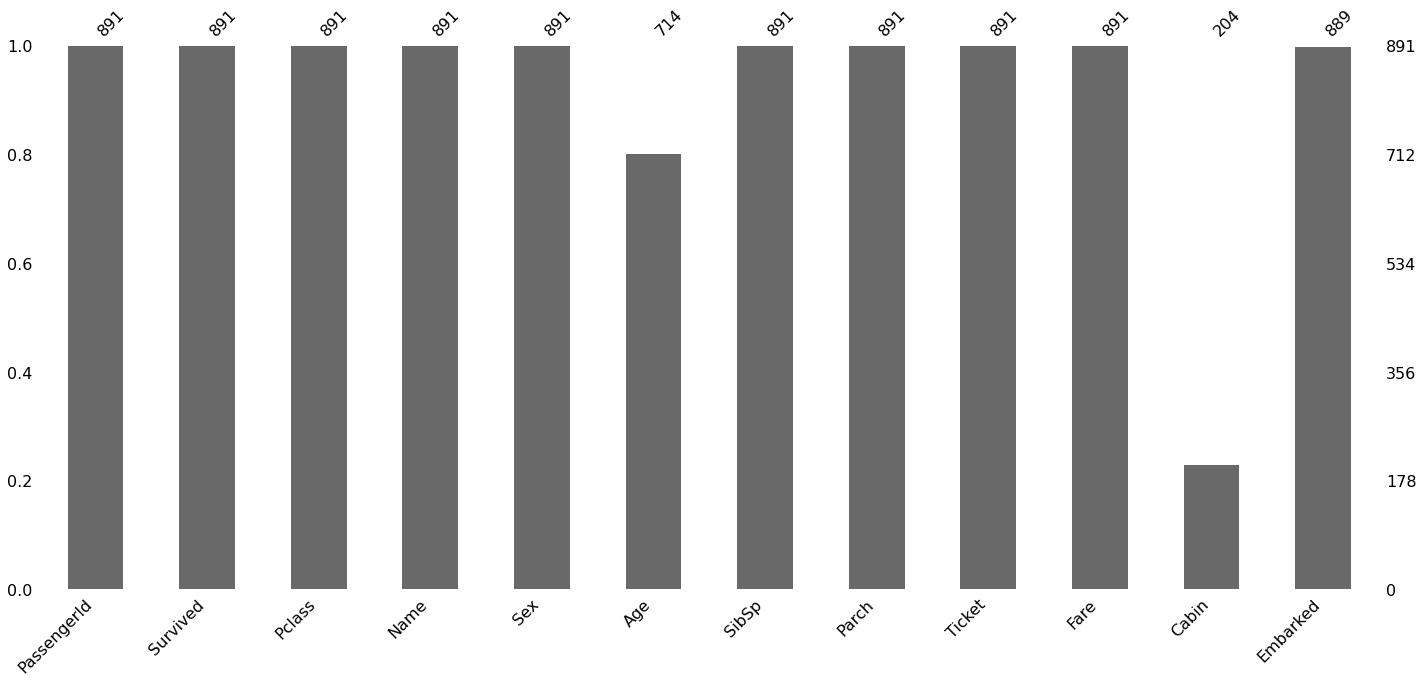

In [7]:
msno.bar(train)

Missing values for Age, Cabin, and Embarked.

<AxesSubplot:>

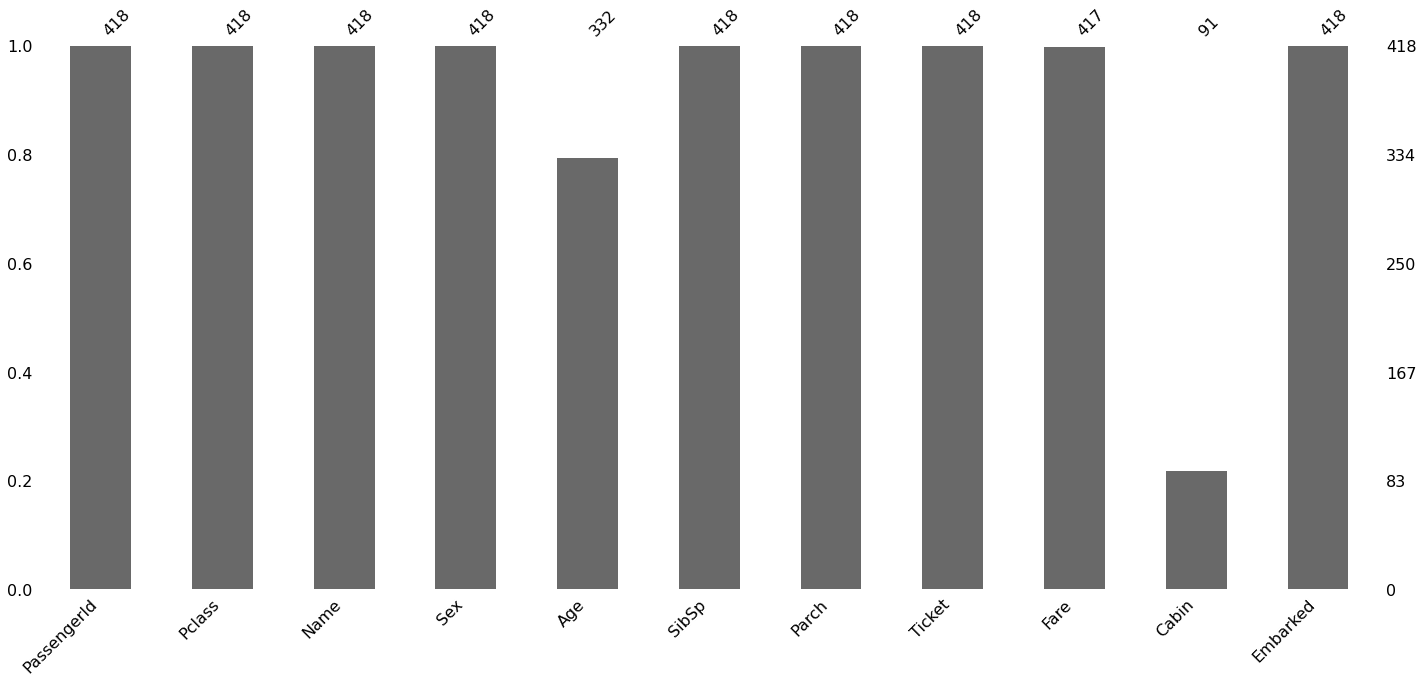

In [8]:
msno.bar(test)

Missing values for Age, Fare, and Cabin.

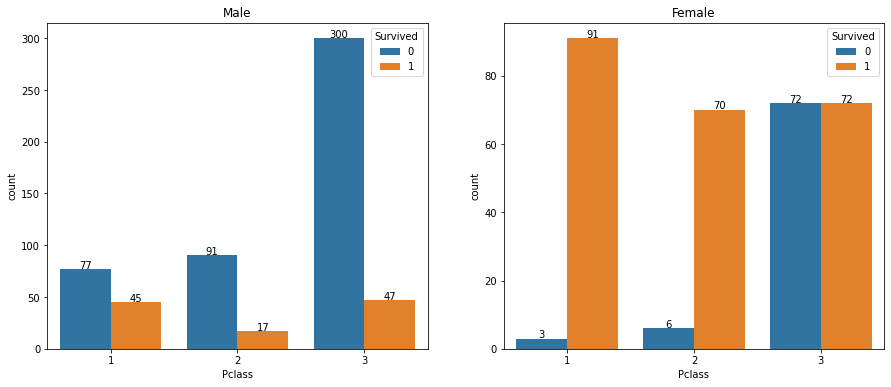

In [9]:
fig,ax = plt.subplots(1, 2,figsize = (15,6))
sns.countplot(x="Pclass",hue = 'Survived',data=train[train['Sex'] == 'male'],ax = ax[0])
sns.countplot(x="Pclass",hue = 'Survived', data=train[train['Sex'] == 'female'],ax = ax[1])
ax[0].set_title('Male')
ax[1].set_title('Female')
for i in np.arange(2):
    for p in ax[i].patches:
        height = p.get_height()
        ax[i].text(p.get_x()+p.get_width()/2., height + .3,height ,ha="center") 

Women in Class 1 and 2 have a high probability of survival.

<AxesSubplot:xlabel='Age', ylabel='Count'>

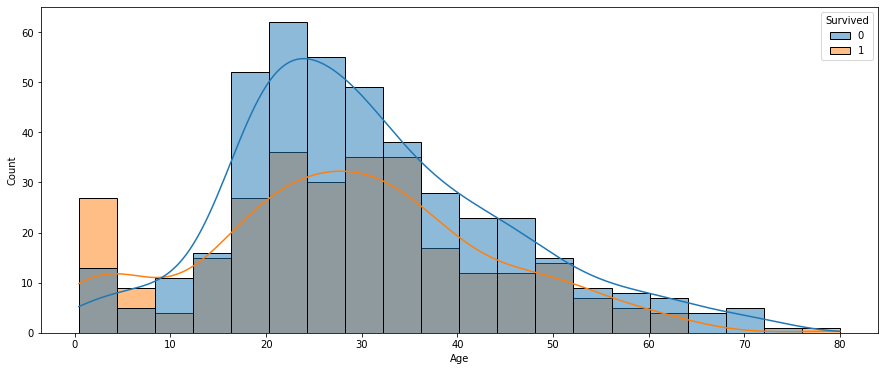

In [10]:
fig,ax = plt.subplots(figsize = (15,6))
sns.histplot(x="Age",kde = True, hue='Survived',data=train)

The child has a high probability of survival.  
A closer look at the data shows that Ticket has multiple with the same ticket number, and the fare is the same amount per ticket number.

## Feature Engineering

In [11]:
test['Survived'] = 9
df = pd.concat([train, test], sort=False,axis=0)

# Add family size and whether you are traveling alone
df['FamilySize'] = df['Parch'] + df['SibSp'] + 1
df['IsAlone'] = 0
df.loc[df['Parch'] + df['SibSp'] == 0 , 'IsAlone'] = 1

# under 15 years old or not
df['IsChild'] = 0
df.loc[df['Age'] < 16 , 'IsChild'] = 1

# Number of people with the same ticket number
df.loc[:, 'TicketSize'] = df.groupby(['Ticket'])['PassengerId'].transform('count')

df = df.drop(['PassengerId','Ticket','Name','Cabin'], axis=1)
df_train = df.query('Survived != 9')
df_test = df.query('Survived == 9').drop(['Survived'], axis=1)

df_train.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,IsChild,TicketSize
0,0,3,male,22.0,1,0,7.2500,S,2,0,0,1
1,1,1,female,38.0,1,0,71.2833,C,2,0,0,2
2,1,3,female,26.0,0,0,7.9250,S,1,1,0,1
3,1,1,female,35.0,1,0,53.1000,S,2,0,0,2
4,0,3,male,35.0,0,0,8.0500,S,1,1,0,1


In [12]:
df_test.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,IsChild,TicketSize
0,3,male,34.5,0,0,7.8292,Q,1,1,0,1
1,3,female,47.0,1,0,7.0000,S,2,0,0,1
2,2,male,62.0,0,0,9.6875,Q,1,1,0,1
3,3,male,27.0,0,0,8.6625,S,1,1,0,1
4,3,female,22.0,1,1,12.2875,S,3,0,0,2


## Predict with PyCaret

In [13]:
clf = setup(data=df_train, target='Survived', 
            numeric_features=['Pclass','SibSp','Parch','FamilySize','TicketSize'], 
            silent= True, session_id=123)

,Description,Value
0,session_id,123
1,Target,Survived
2,Target Type,Binary
3,Label Encoded,"0: 0, 1: 1"
4,Original Data,"(891, 12)"
5,Missing Values,True
6,Numeric Features,7
7,Categorical Features,4
8,Ordinal Features,False
9,High Cardinality Features,False


In [14]:
X_train = get_config('X_train')
X_train

,Pclass,Age,SibSp,Parch,Fare,FamilySize,TicketSize,Sex_female,Embarked_C,Embarked_Q,Embarked_S,Embarked_not_available,IsAlone_0,IsChild_0
416,2.0,34.0,1.0,1.0,32.5000,3.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
801,2.0,31.0,1.0,1.0,26.2500,3.0,3.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
512,1.0,36.0,0.0,0.0,26.2875,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
455,3.0,29.0,0.0,0.0,7.8958,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
757,2.0,18.0,0.0,0.0,11.5000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2.0,34.0,0.0,1.0,23.0000,2.0,2.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0
322,2.0,30.0,0.0,0.0,12.3500,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0
382,3.0,32.0,0.0,0.0,7.9250,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
365,3.0,30.0,0.0,0.0,7.2500,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [15]:
lightgbm = create_model('lightgbm')
tuned = tune_model(lightgbm)
predh = predict_model(tuned)
final = finalize_model(tuned)
pred = predict_model(final, data=df_test)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,0.8571,0.8789,0.6800,0.9444,0.7907,0.6866,0.7079
1,0.8095,0.8716,0.6400,0.8421,0.7273,0.5851,0.5981
2,0.7937,0.8132,0.6800,0.7727,0.7234,0.5599,0.5628
3,0.8226,0.8027,0.6000,0.9375,0.7317,0.6085,0.6423
4,0.7903,0.7769,0.5417,0.8667,0.6667,0.5253,0.5562
5,0.8387,0.9221,0.7083,0.8500,0.7727,0.6493,0.6558
6,0.7742,0.8629,0.5417,0.8125,0.6500,0.4930,0.5151
7,0.8710,0.9134,0.7083,0.9444,0.8095,0.7149,0.7319
8,0.8387,0.8586,0.7500,0.8182,0.7826,0.6548,0.6564
9,0.8226,0.8904,0.5833,0.9333,0.7179,0.5984,0.6335


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8396,0.8847,0.6633,0.8667,0.7514,0.6361,0.6485


In [16]:
pred

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,IsChild,TicketSize,Label,Score
0,3,male,34.5,0,0,7.8292,Q,1,1,0,1,0,0.7814
1,3,female,47.0,1,0,7.0000,S,2,0,0,1,0,0.6218
2,2,male,62.0,0,0,9.6875,Q,1,1,0,1,0,0.7704
3,3,male,27.0,0,0,8.6625,S,1,1,0,1,0,0.7249
4,3,female,22.0,1,1,12.2875,S,3,0,0,2,0,0.5209
...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,3,male,NaN,0,0,8.0500,S,1,1,0,1,0,0.7724
414,1,female,39.0,0,0,108.9000,C,1,1,0,3,1,0.6928
415,3,male,38.5,0,0,7.2500,S,1,1,0,1,0,0.7898
416,3,male,NaN,0,0,8.0500,S,1,1,0,1,0,0.7724


## Model Analysis

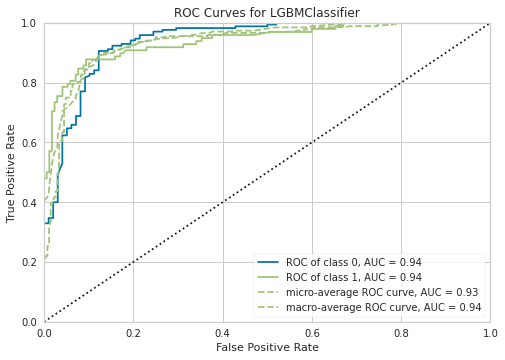

In [17]:
plot_model(final, plot="auc") 

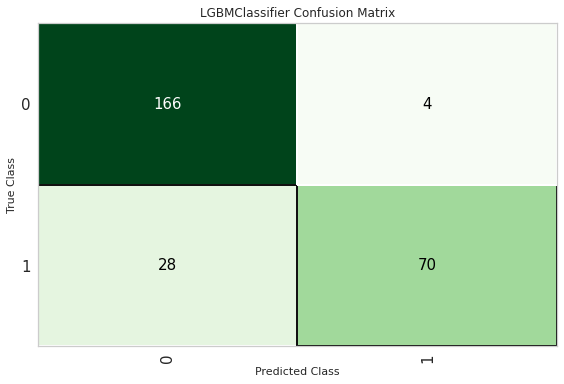

In [18]:
plot_model(final, plot="confusion_matrix") 

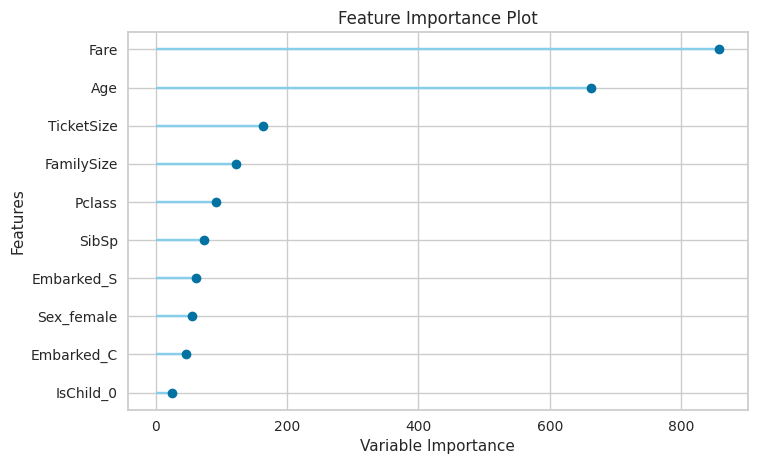

In [19]:
plot_model(final, plot="feature") 

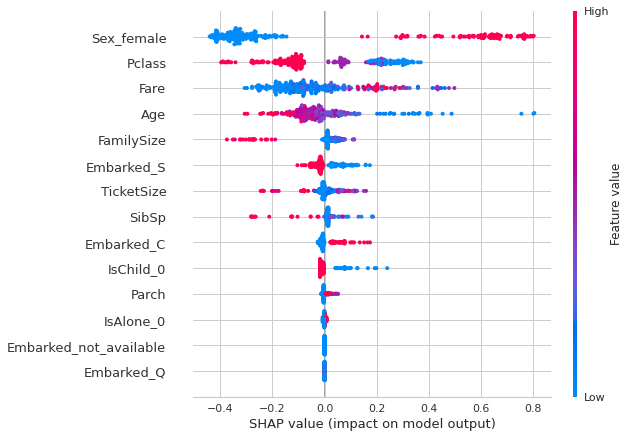

In [20]:
interpret_model(final)

In [21]:
interpret_model(final, plot = 'reason', observation=12)

## Submit

In [22]:
submission = pd.read_csv("../input/titanic/gender_submission.csv")
submission.Survived = pred.Label
submission.to_csv('lightgbm_submission.csv',index=False)
submission

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0
